## ICESat-2 SlideRule Demo

Process ATL03 data from the Grand Mesa, CO region and produce a customized ATL06 dataset.

### What is demonstrated

* The `icesat2.atl06p` API is used to perform a SlideRule parallel processing request of the Grand Mesa region
* The `icesat2.cmr` and `icesat2.h5p` API's are used to manually retrieve specific ATL06 datasets corresponding to the Grand Mesa region
* The `pyproj` and `shapely` packages are used to subset ATL06 data that was manually retrieved
* The `matplotlib` package is used to plot the data processed by SlideRule alongside the manually retrieved and subsetted data

### Points of interest

The resulting datasets plotted at the bottom of the notebook show that existing ATL06 data is not available for the entire Grand Mesa region.  By using the SlideRule API to process ATL03 data and produce a customized ATL06 dataset, elevation data can be returned for the entire region of interest.

In [2]:
import sys
import logging
import concurrent.futures
import time
from datetime import datetime
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import Transformer, CRS
from shapely.geometry import Polygon, Point, MultiPolygon, mapping
from sliderule import sliderule, icesat2, earthdata, h5
import geojson
import numpy as np


## SlideRule Configuration

In [3]:
# Configure ICESat-2 API
icesat2.init("slideruleearth.io", verbose=True)

In [4]:
# Specify region of interest from geojson
poly_fn = '../data/misc/cleaned_tuol.geojson'
region = sliderule.toregion(poly_fn)["poly"]
#region

In [4]:
geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=region)

HTTPError: 504 Server Error: Gateway Time-out for url: https://tnmaccess.nationalmap.gov/api/v1/products?datasets=Digital+Elevation+Model+%28DEM%29+1+meter&polygon=-119.268903+37.739453%2C+-119.268562+37.739459%2C+-119.261799+37.740941%2C+-119.260786+37.741231%2C+-119.25613+37.744835%2C+-119.255466+37.745388%2C+-119.204112+37.79313%2C+-119.203139+37.79477%2C+-119.201256+37.800212%2C+-119.200964+37.80184%2C+-119.198659+37.884879%2C+-119.198683+37.885689%2C+-119.310777+38.044931%2C+-119.322862+38.059561%2C+-119.328543+38.066207%2C+-119.346199+38.083697%2C+-119.34831+38.085547%2C+-119.496466+38.157641%2C+-119.501662+38.159422%2C+-119.587153+38.185682%2C+-119.588883+38.186184%2C+-119.58991+38.186161%2C+-119.592619+38.185291%2C+-119.597343+38.183294%2C+-119.616071+38.170714%2C+-119.625389+38.163207%2C+-119.625721+38.16293%2C+-119.626386+38.162374%2C+-119.796731+37.978955%2C+-119.798339+37.958373%2C+-119.798288+37.957023%2C+-119.797162+37.954347%2C+-119.784964+37.938688%2C+-119.782846+37.936

In [3]:
sliderule.update_available_servers()

(7, 0)

## Specify Region of Interest

In [17]:
# Specify region of interest from geojson
poly_fn = '../data/misc/sierras_polygon_gmba.geojson'
region = sliderule.toregion(poly_fn)["poly"]
region

[{'lon': -118.73127363763477, 'lat': 34.81861111111108},
 {'lon': -118.72809167271663, 'lat': 34.81959581163194},
 {'lon': -118.4099684230535, 'lat': 34.92758734809024},
 {'lon': -118.38008562208236, 'lat': 34.938207465277685},
 {'lon': -118.366019058499, 'lat': 34.948030056423576},
 {'lon': -118.35120786629643, 'lat': 34.960041775173536},
 {'lon': -118.07996366755773, 'lat': 35.19089301215274},
 {'lon': -118.05844674877564, 'lat': 35.217247992621495},
 {'lon': -118.01278840050536, 'lat': 35.285977647569425},
 {'lon': -118.00945588225983, 'lat': 35.29175971137148},
 {'lon': -117.86294308071204, 'lat': 35.652546657986065},
 {'lon': -117.86265418108383, 'lat': 35.68829291449653},
 {'lon': -117.88239294299981, 'lat': 35.86383816189233},
 {'lon': -117.89894973999758, 'lat': 35.98214870876728},
 {'lon': -117.9031286120832, 'lat': 35.99883978949647},
 {'lon': -118.0406692491239, 'lat': 36.518033311631925},
 {'lon': -118.06983590453795, 'lat': 36.61570990668396},
 {'lon': -118.09313098018606,

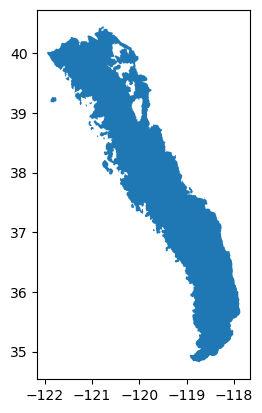

In [18]:
# Read geojson with geopandas
pregion = gpd.read_file(poly_fn)
pregion.plot();

In [24]:
gdf = gpd.read_file(poly_fn)

In [27]:
# create a multipolygon with simplified internal polygons (needed to get convex hull)
polygons = list(gdf.geometry)
cleaned_polygons = [polygon.convex_hull for polygon in polygons]
cleaned_multipoly = MultiPolygon(cleaned_polygons)

In [30]:
# build geojson of multipolygon
cleaned_glims_geojson = "../data/misc/cleaned_sierra.geojson"
geojson_obj = geojson.Feature(geometry=mapping(cleaned_multipoly))
with open(cleaned_glims_geojson, "w") as geojson_file:
    geojson.dump(geojson_obj, geojson_file)

In [19]:
# Prepare coordinate lists for plotting the region of interest polygon
region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

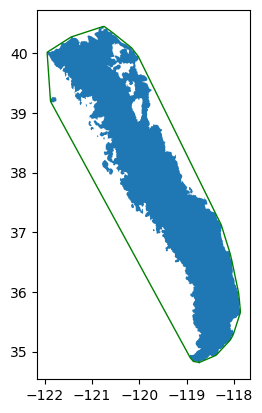

In [36]:
fig, ax = plt.subplots()
pregion.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

### Query USGS "The National Map" API for 3DEP 1m products in area of interest

In [7]:
# Specify region of interest from geojson
poly_fn = '../data/misc/cleaned_tuol.geojson'
region = sliderule.toregion(poly_fn)["poly"]
#region

In [8]:
# Prepare coordinate lists for plotting the region of interest polygon
region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

In [15]:
tuol = gpd.read_file('../data/misc/cleaned_tuol.geojson')

In [17]:
tuol.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

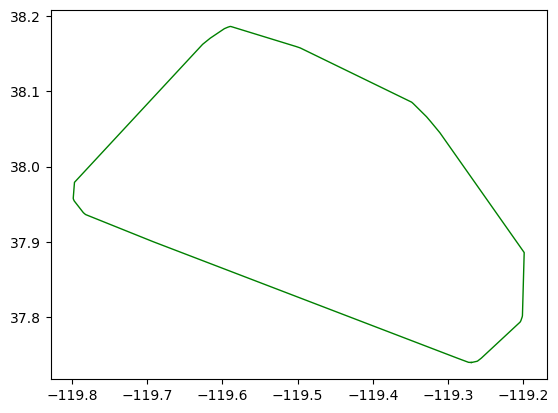

In [14]:
fig, ax = plt.subplots()
#tuol.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

In [8]:
geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=region)

TypeError: list indices must be integers or slices, not str

### Test 1m sampling in Grand Mesa:

In [142]:
region = [  {"lon": -108.3435200747503, "lat": 38.89102961045247},
            {"lon": -107.7677425431139, "lat": 38.90611184543033},
            {"lon": -107.7818591266989, "lat": 39.26613714985466},
            {"lon": -108.3605610678553, "lat": 39.25086131372244},
            {"lon": -108.3435200747503, "lat": 38.89102961045247}  ]

# @pytest.mark.network
# class Test3DEP_1meter:
#     def test_sample(self, init):
#         geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=region)
#         gdf = raster.sample("usgs3dep-1meter-dem", [[-108.0,39.0]], {"catalog": geojson})
#         assert init
#         assert len(gdf) >= 4

In [143]:
region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

In [144]:
geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=region)

In [21]:
geojson

'{"type": "FeatureCollection", "features": [{"type": "Feature", "id": "5eaa4a0582cefae35a21ee8c", "geometry": {"type": "Polygon", "coordinates": [[[-108.117274181, 38.9003581843], [-107.998021739, 38.9003581843], [-107.998021739, 38.987435717], [-108.117274181, 38.987435717], [-108.117274181, 38.9003581843]]]}, "properties": {"datetime": "2020-11-17T19:08:25.219000+01:00", "url": "https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_MesaCo_QL2_UTM12_2016/TIFF/USGS_one_meter_x23y432_CO_MesaCo_QL2_UTM12_2016.tif"}}, {"type": "Feature", "id": "5eaa4a0582cefae35a21ee8e", "geometry": {"type": "Polygon", "coordinates": [[[-108.121233424, 38.9903575086], [-108.001829768, 38.9903575086], [-108.001829768, 39.0774149519], [-108.121233424, 39.0774149519], [-108.121233424, 38.9903575086]]]}, "properties": {"datetime": "2020-11-17T19:08:25.977000+01:00", "url": "https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_MesaCo_QL2_UTM12_2016/TIFF/USGS_one_meter_x23

In [145]:
# Build ATL06 Request
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}

In [146]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_1m_gm = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_1m_gm["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_1m_gm["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_1m_gm.shape[0]))

Completed in 232.561 seconds of wall-clock time
Reference Ground Tracks: [ 714  737 1156 1179  211  234  295]
Cycles: [ 9 10 11 12 13]
Received 78248 elevations


In [116]:
#gdf_1m_gm = atl06_sr_1m_gm[atl06_sr_1m_gm["3dep.value"].notna()]

In [148]:
gdf_1m_gm = atl06_sr_1m_gm.copy()

In [149]:
def getFirstNonNanValue(x):
    if np.isnan(x['3dep.value']).all():
        return np.nan
    elif type(x["3dep.value"]) == float:
        return x['3dep.value']
    else:
        return x["3dep.value"][np.isfinite(x['3dep.value'])][0]
    
gdf_1m_gm["3dep"] = gdf_1m_gm.apply(lambda x: getFirstNonNanValue(x), axis=1)

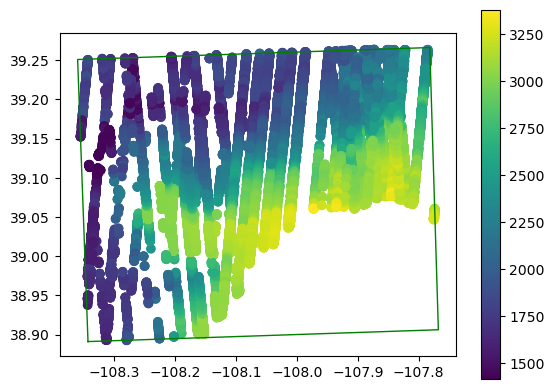

In [150]:
fig, ax = plt.subplots()

gdf_1m_gm.plot(column='3dep', ax=ax, legend=True)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

In [34]:
#gdf = gdf[gdf["3dep"] > -9999.0]

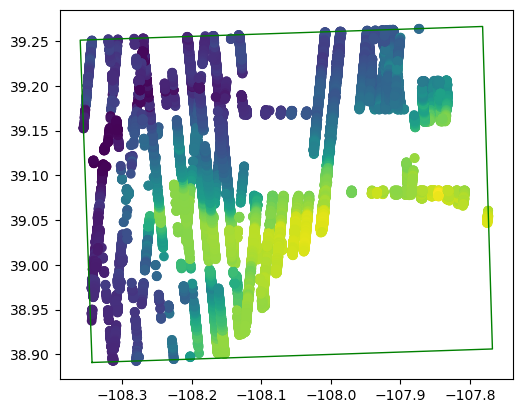

In [38]:
# fig, ax = plt.subplots()

# gdf.plot(column='3dep', ax=ax)
# ax.plot(region_lon, region_lat, linewidth=1, color='g');

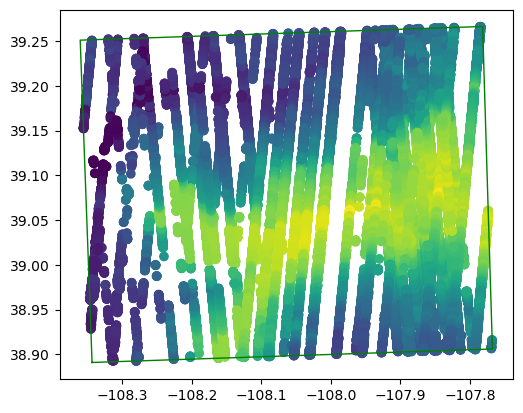

In [40]:
fig, ax = plt.subplots()

atl06_sr.plot(column='h_mean', ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

### Now test the 10m sampling over Grand Mesa:

In [151]:
region = [  {"lon": -108.3435200747503, "lat": 38.89102961045247},
            {"lon": -107.7677425431139, "lat": 38.90611184543033},
            {"lon": -107.7818591266989, "lat": 39.26613714985466},
            {"lon": -108.3605610678553, "lat": 39.25086131372244},
            {"lon": -108.3435200747503, "lat": 38.89102961045247}  ]

# @pytest.mark.network
# class Test3DEP_1meter:
#     def test_sample(self, init):
#         geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=region)
#         gdf = raster.sample("usgs3dep-1meter-dem", [[-108.0,39.0]], {"catalog": geojson})
#         assert init
#         assert len(gdf) >= 4

In [152]:
region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

In [153]:
geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 10 meter', polygon=region)

In [154]:
# Build ATL06 Request
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}

In [155]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_10m_gm = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_10m_gm["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_10m_gm["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_10m_gm.shape[0]))

Completed in 16.918 seconds of wall-clock time
Reference Ground Tracks: [ 714  737 1156 1179  211  234  295]
Cycles: [ 9 10 11 12 13]
Received 78248 elevations


In [156]:
gdf_10m_gm = atl06_sr_10m_gm.copy()

In [157]:
def getFirstNonNanValue(x):
    if np.isnan(x['3dep.value']).all():
        return np.nan
    elif type(x["3dep.value"]) == float:
        return x['3dep.value']
    else:
        return x["3dep.value"][np.isfinite(x['3dep.value'])][0]
    
gdf_10m_gm["3dep"] = gdf_10m_gm.apply(lambda x: getFirstNonNanValue(x), axis=1)

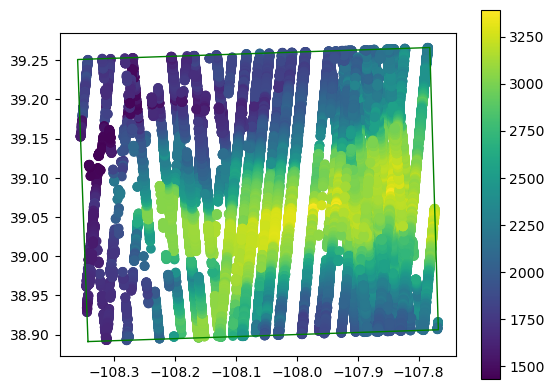

In [158]:
fig, ax = plt.subplots()

gdf_10m_gm.plot(column='3dep', ax=ax, legend=True)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

In [159]:
gdf_1m_gm

,pflags,spot,rgt,dh_fit_dx,w_surface_window_final,h_mean,cycle,segment_id,region,y_atc,...,n_fit_photons,rms_misfit,x_atc,h_sigma,geometry,3dep.flags,3dep.value,3dep.file_id,3dep.time,3dep
time,,,,,,,,,,,,,,,,,,,,,
2020-11-09 22:43:46.697648640,0,3,714,0.073997,3.000000,1832.711363,9,784511,6,2838.034668,...,11,0.131460,15713236.0,0.039994,POINT (-108.28383 39.16283),[0],[1833.120604084157],[68719476738],[1289675416.0],1833.120604
2020-11-09 22:43:46.708872448,0,3,714,0.076683,3.000000,1839.334661,9,784515,6,2838.033936,...,32,0.167584,15713316.0,0.029915,POINT (-108.28392 39.16211),[0],[1839.5481844904825],[68719476738],[1289675416.0],1839.548184
2020-11-09 22:43:46.711683328,0,3,714,0.083977,3.000000,1840.999437,9,784516,6,2838.043945,...,50,0.307088,15713336.0,0.048587,POINT (-108.28395 39.16193),[0],[1840.5022462899228],[68719476738],[1289675416.0],1840.502246
2020-11-09 22:43:46.714496512,0,3,714,0.083841,3.000000,1842.646807,9,784517,6,2838.055420,...,36,0.410837,15713356.0,0.069381,POINT (-108.28397 39.16175),[0],[1842.9390955624278],[68719476738],[1289675416.0],1842.939096
2020-11-09 22:43:46.717319424,0,3,714,0.061703,3.000000,1844.034558,9,784518,6,2838.064941,...,30,0.256882,15713377.0,0.047131,POINT (-108.28399 39.16157),[0],[1844.1890544158775],[68719476738],[1289675416.0],1844.189054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-11 18:29:20.517326848,0,1,295,-0.034956,3.000000,1755.654937,13,217744,2,-6490.607910,...,19,0.132532,4366711.0,0.031949,POINT (-108.31989 39.24965),[0],[1755.9596013627495],[34359738372],[1289675417.0],1755.959601
2021-10-11 18:29:20.520121856,0,1,295,0.003212,3.000000,1755.124881,13,217745,2,-6490.530273,...,24,0.141275,4366731.0,0.039023,POINT (-108.31991 39.24983),[0],[1755.526047056639],[34359738372],[1289675417.0],1755.526047
2021-10-11 18:29:20.522920704,0,1,295,-0.002777,3.000000,1755.142042,13,217746,2,-6490.449707,...,18,0.147117,4366751.0,0.083019,POINT (-108.31994 39.25),[0],[1754.3836305229754],[34359738372],[1289675417.0],1754.383631


In [160]:
gdf_10m_gm

,pflags,spot,rgt,dh_fit_dx,w_surface_window_final,h_mean,cycle,segment_id,region,y_atc,...,n_fit_photons,rms_misfit,x_atc,h_sigma,geometry,3dep.flags,3dep.value,3dep.file_id,3dep.time,3dep
time,,,,,,,,,,,,,,,,,,,,,
2020-11-09 22:43:46.697648640,0,3,714,0.073997,3.000000,1832.711363,9,784511,6,2838.034668,...,11,0.131460,15713236.0,0.039994,POINT (-108.28383 39.16283),0,1849.261234,81604378624,1.354129e+09,1849.261234
2020-11-09 22:43:46.708872448,0,3,714,0.076683,3.000000,1839.334661,9,784515,6,2838.033936,...,32,0.167584,15713316.0,0.029915,POINT (-108.28392 39.16211),0,1855.930896,81604378624,1.354129e+09,1855.930896
2020-11-09 22:43:46.711683328,0,3,714,0.083977,3.000000,1840.999437,9,784516,6,2838.043945,...,50,0.307088,15713336.0,0.048587,POINT (-108.28395 39.16193),0,1857.262313,81604378624,1.354129e+09,1857.262313
2020-11-09 22:43:46.714496512,0,3,714,0.083841,3.000000,1842.646807,9,784517,6,2838.055420,...,36,0.410837,15713356.0,0.069381,POINT (-108.28397 39.16175),0,1859.505718,81604378624,1.354129e+09,1859.505718
2020-11-09 22:43:46.717319424,0,3,714,0.061703,3.000000,1844.034558,9,784518,6,2838.064941,...,30,0.256882,15713377.0,0.047131,POINT (-108.28399 39.16157),0,1861.327857,81604378624,1.354129e+09,1861.327857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-11 18:29:20.517326848,0,1,295,-0.034956,3.000000,1755.654937,13,217744,2,-6490.607910,...,19,0.132532,4366711.0,0.031949,POINT (-108.31989 39.24965),0,1772.224875,25769803776,1.354129e+09,1772.224875
2021-10-11 18:29:20.520121856,0,1,295,0.003212,3.000000,1755.124881,13,217745,2,-6490.530273,...,24,0.141275,4366731.0,0.039023,POINT (-108.31991 39.24983),0,1771.422024,25769803776,1.354129e+09,1771.422024
2021-10-11 18:29:20.522920704,0,1,295,-0.002777,3.000000,1755.142042,13,217746,2,-6490.449707,...,18,0.147117,4366751.0,0.083019,POINT (-108.31994 39.25),0,1771.519074,25769803776,1.354129e+09,1771.519074


In [161]:
gdf_10m_gm['1m_10m_dif'] = gdf_1m_gm['3dep'] - gdf_10m_gm['3dep']

<Axes: >

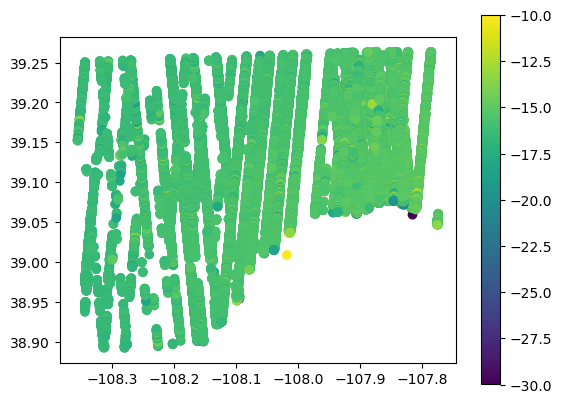

In [164]:
gdf_10m_gm.plot(column='1m_10m_dif', legend=True, vmin=-30, vmax=-10)

In [165]:
np.sqrt(len(gdf_10m_gm['3dep']))

np.float64(279.7284397411175)

''

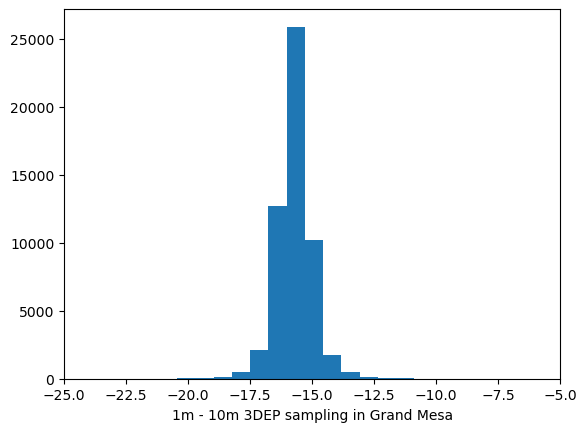

In [174]:
fig, ax = plt.subplots()

ax.hist(gdf_10m_gm['1m_10m_dif'], bins = 600)
ax.set_xlim(-25, -5)
ax.set_xlabel('1m - 10m 3DEP sampling in Grand Mesa')
;

In [173]:
gdf_10m_gm['1m_10m_dif'].describe()

count    54071.000000
mean       -15.714384
std          2.032904
min       -236.458710
25%        -16.090996
50%        -15.721914
75%        -15.318239
max        204.407535
Name: 1m_10m_dif, dtype: float64

### Now test over tuolumne using a bounding box instead of a polygon:

In [22]:
# rough tuolumne bounding box
38.2, -119.8, 37.7, -119.2

(38.2, -119.8, 37.7, -119.2)

In [55]:
#grand mesa bounding box:
region = [  {"lon": -119.8, "lat": 37.7},
            {"lon": -119.2, "lat": 37.7},
            {"lon": -119.2, "lat": 38.2},
            {"lon": -119.8, "lat": 38.2},
            {"lon": -119.8, "lat": 37.7}  ]

# @pytest.mark.network
# class Test3DEP_1meter:
#     def test_sample(self, init):
#         geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=region)
#         gdf = raster.sample("usgs3dep-1meter-dem", [[-108.0,39.0]], {"catalog": geojson})
#         assert init
#         assert len(gdf) >= 4

In [15]:
region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

In [16]:
geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=region)

In [ ]:
geojson

'{"type": "FeatureCollection", "features": [{"type": "Feature", "id": "5eaa4a0582cefae35a21ee8c", "geometry": {"type": "Polygon", "coordinates": [[[-108.117274181, 38.9003581843], [-107.998021739, 38.9003581843], [-107.998021739, 38.987435717], [-108.117274181, 38.987435717], [-108.117274181, 38.9003581843]]]}, "properties": {"datetime": "2020-11-17T19:08:25.219000+01:00", "url": "https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_MesaCo_QL2_UTM12_2016/TIFF/USGS_one_meter_x23y432_CO_MesaCo_QL2_UTM12_2016.tif"}}, {"type": "Feature", "id": "5eaa4a0582cefae35a21ee8e", "geometry": {"type": "Polygon", "coordinates": [[[-108.121233424, 38.9903575086], [-108.001829768, 38.9903575086], [-108.001829768, 39.0774149519], [-108.121233424, 39.0774149519], [-108.121233424, 38.9903575086]]]}, "properties": {"datetime": "2020-11-17T19:08:25.977000+01:00", "url": "https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_MesaCo_QL2_UTM12_2016/TIFF/USGS_one_meter_x23

In [17]:
# Build ATL06 Request
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}

In [18]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 71.921 seconds of wall-clock time
Reference Ground Tracks: [ 684  707 1126 1149  265  623 1210  181]
Cycles: [ 9 10 11 12 13]
Received 113632 elevations


In [19]:
gdf = atl06_sr[atl06_sr["3dep.value"].notna()]

In [20]:
def getFirstNonNanValue(x):
    if np.isnan(x['3dep.value']).all():
        return np.nan
    else:
        return x["3dep.value"][np.isfinite(x['3dep.value'])][0]
    
gdf["3dep"] = gdf.apply(lambda x: getFirstNonNanValue(x), axis=1)

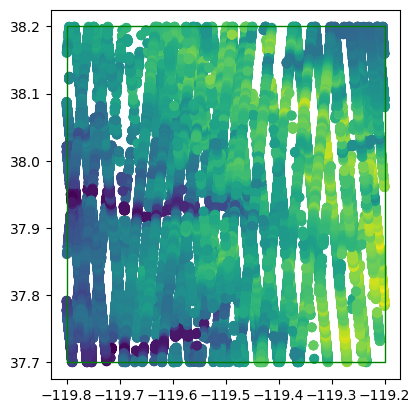

In [21]:
fig, ax = plt.subplots()

gdf.plot(column='3dep', ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

### Now test over tuolumne using original polygon:

In [23]:
tuol = gpd.read_file('../data/misc/UpperTuolRiverBasinOutline.geojson')

In [37]:
# Specify region of interest from geojson
poly_fn = '../data/misc/UpperTuolRiverBasinOutline.geojson'
region = sliderule.toregion(poly_fn)["poly"]

In [25]:
# Prepare coordinate lists for plotting the region of interest polygon
region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

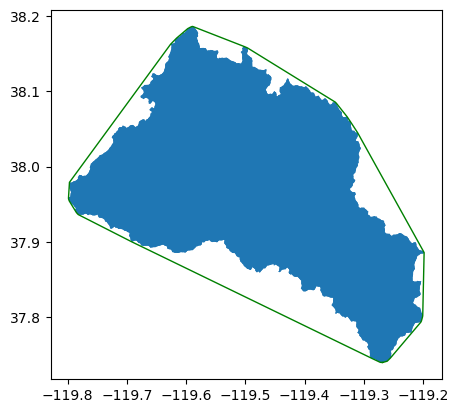

In [27]:
fig, ax = plt.subplots()
tuol.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

In [33]:
tuol[tuol['DN']==0]

,DN,geometry
0,0,"MULTIPOLYGON (((-119.79834 37.95837, -119.798 ..."


In [35]:
region = tuol[tuol['DN']==0]

In [38]:
geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=region)

HTTPError: 504 Server Error: Gateway Time-out for url: https://tnmaccess.nationalmap.gov/api/v1/products?datasets=Digital+Elevation+Model+%28DEM%29+1+meter&polygon=-119.26890260680983+37.73945270716548%2C+-119.26856237948883+37.73945925888795%2C+-119.26179893543954+37.74094102607886%2C+-119.2607864494171+37.741230805345104%2C+-119.25612978391472+37.74483456877925%2C+-119.2554656810001+37.74538797649563%2C+-119.20411216437697+37.79313001174896%2C+-119.20313886310075+37.79477030245469%2C+-119.20125631132412+37.80021243211857%2C+-119.2009639187066+37.80183997424256%2C+-119.1986589224611+37.884878809530306%2C+-119.19868303509632+37.885689387654935%2C+-119.31077683155955+38.04493120264124%2C+-119.32286183225777+38.059561101390095%2C+-119.32854302840818+38.06620688715452%2C+-119.34619876644359+38.08369729612237%2C+-119.34831007151678+38.08554740214389%2C+-119.49646570517092+38.15764070164313%2C+-119.50166190110505+38.15942229534689%2C+-119.58715311270889+38.185681591980654%2C+-119.5888833003

In [ ]:
geojson

'{"type": "FeatureCollection", "features": [{"type": "Feature", "id": "5eaa4a0582cefae35a21ee8c", "geometry": {"type": "Polygon", "coordinates": [[[-108.117274181, 38.9003581843], [-107.998021739, 38.9003581843], [-107.998021739, 38.987435717], [-108.117274181, 38.987435717], [-108.117274181, 38.9003581843]]]}, "properties": {"datetime": "2020-11-17T19:08:25.219000+01:00", "url": "https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_MesaCo_QL2_UTM12_2016/TIFF/USGS_one_meter_x23y432_CO_MesaCo_QL2_UTM12_2016.tif"}}, {"type": "Feature", "id": "5eaa4a0582cefae35a21ee8e", "geometry": {"type": "Polygon", "coordinates": [[[-108.121233424, 38.9903575086], [-108.001829768, 38.9903575086], [-108.001829768, 39.0774149519], [-108.121233424, 39.0774149519], [-108.121233424, 38.9903575086]]]}, "properties": {"datetime": "2020-11-17T19:08:25.977000+01:00", "url": "https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_MesaCo_QL2_UTM12_2016/TIFF/USGS_one_meter_x23

### Test the 1m 3DEP sampling over the Tuolumne bounding box:

In [64]:
# Build ATL06 Request
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}

In [65]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_1m = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 61.887 seconds of wall-clock time
Reference Ground Tracks: [ 684  707 1126 1149  265  623 1210  181]
Cycles: [ 9 10 11 12 13]
Received 113632 elevations


In [88]:
atl06_sr_1m.crs

<Geographic 3D CRS: EPSG:7912>
Name: ITRF2014
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
- h[up]: Ellipsoidal height (metre)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: International Terrestrial Reference Frame 2014
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [89]:
atl06_sr_10m.crs

<Geographic 3D CRS: EPSG:7912>
Name: ITRF2014
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
- h[up]: Ellipsoidal height (metre)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: International Terrestrial Reference Frame 2014
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [68]:
gdf_1m = atl06_sr_1m[atl06_sr_1m["3dep.value"].notna()]

In [69]:
def getFirstNonNanValue(x):
    if np.isnan(x['3dep.value']).all():
        return np.nan
    else:
        return x["3dep.value"][np.isfinite(x['3dep.value'])][0]
    
gdf_1m["3dep"] = gdf_1m.apply(lambda x: getFirstNonNanValue(x), axis=1)

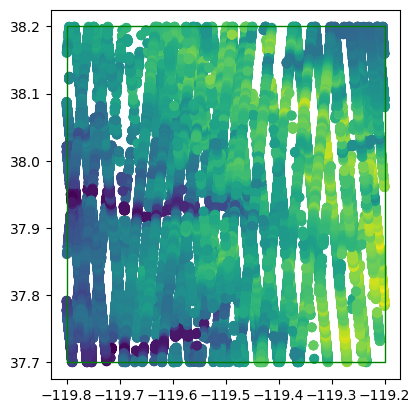

In [70]:
fig, ax = plt.subplots()

gdf_1m.plot(column='3dep', ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

### Test over the entire Sierra Nevada:

In [5]:
poly = gpd.read_file('../data/misc/sierras_polygon_gmba.geojson')

<Axes: >

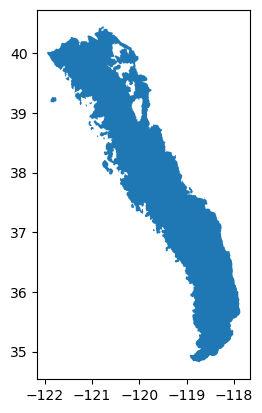

In [41]:
poly.plot()

In [42]:
poly.bounds

,minx,miny,maxx,maxy
0,-121.948903,34.818611,-117.862654,40.446988


In [6]:
#grand mesa bounding box:
region = [  {"lon": -121.948903, "lat": 34.818611},
            {"lon": -117.862654, "lat": 34.818611},
            {"lon": -117.862654, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 34.818611}  ]

# @pytest.mark.network
# class Test3DEP_1meter:
#     def test_sample(self, init):
#         geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=region)
#         gdf = raster.sample("usgs3dep-1meter-dem", [[-108.0,39.0]], {"catalog": geojson})
#         assert init
#         assert len(gdf) >= 4

In [190]:
region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

In [191]:
geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=region)

In [192]:
# Build ATL06 Request
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}

In [193]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_1m_sierras = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_1m_sierras["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_1m_sierras["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_1m_sierras.shape[0]))

Completed in 1674.404 seconds of wall-clock time


KeyError: 'rgt'

In [194]:
atl06_sr_1m_sierras

,geometry


### 1m sampling does not run over the Sierra. Split bounding box to run over smaller regions:

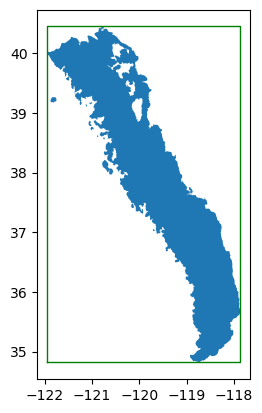

In [199]:
region = [  {"lon": -121.948903, "lat": 34.818611},
            {"lon": -117.862654, "lat": 34.818611},
            {"lon": -117.862654, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 34.818611}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

fig, ax = plt.subplots()
poly.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

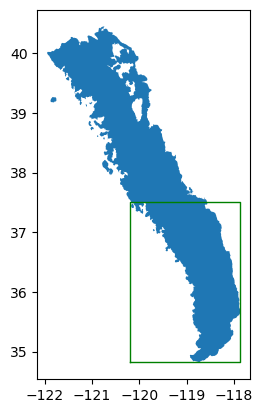

In [7]:
south_region = [  {"lon": -120.2, "lat": 34.818611},
            {"lon": -117.862654, "lat": 34.818611},
            {"lon": -117.862654, "lat": 37.5},
            {"lon": -120.2, "lat": 37.5},
            {"lon": -120.2, "lat": 34.818611}  ]

region_lon = [e["lon"] for e in south_region]
region_lat = [e["lat"] for e in south_region]

fig, ax = plt.subplots()
poly.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

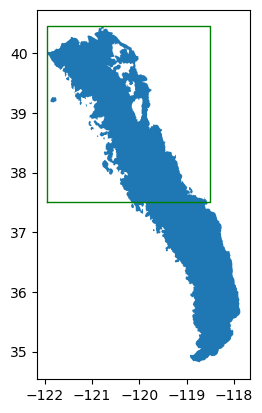

In [8]:
north_region = [  {"lon": -121.948903, "lat": 37.5},
            {"lon": -118.5, "lat": 37.5},
            {"lon": -118.5, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 37.5}  ]

region_lon = [e["lon"] for e in north_region]
region_lat = [e["lat"] for e in north_region]

fig, ax = plt.subplots()
poly.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

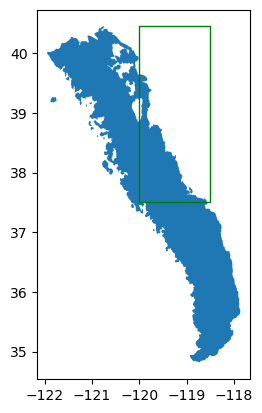

In [215]:
ne_region = [  {"lon": -120, "lat": 37.5},
            {"lon": -118.5, "lat": 37.5},
            {"lon": -118.5, "lat": 40.446988},
            {"lon": -120, "lat": 40.446988},
            {"lon": -120, "lat": 37.5}  ]

region_lon = [e["lon"] for e in ne_region]
region_lat = [e["lat"] for e in ne_region]

fig, ax = plt.subplots()
poly.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

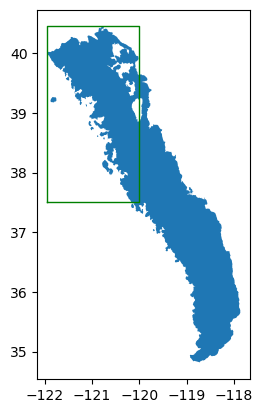

In [217]:
nw_region = [  {"lon": -121.948903, "lat": 37.5},
            {"lon": -120, "lat": 37.5},
            {"lon": -120, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 37.5}  ]

region_lon = [e["lon"] for e in nw_region]
region_lat = [e["lat"] for e in nw_region]

fig, ax = plt.subplots()
poly.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

#### Run for south part of Sierras:

In [9]:
geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=south_region)

In [10]:
# Build ATL06 Request
parms = {
    "poly": south_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}

In [11]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_1m_sierras_south = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_1m_sierras_south["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_1m_sierras_south["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_1m_sierras_south.shape[0]))

Completed in 2208.869 seconds of wall-clock time
Reference Ground Tracks: [ 326  501  562  623  707  768 1004 1065 1126 1149 1210  120  181  204
  265 1088   59  585  646  143  242  684]
Cycles: [ 9 10 11 12 13]
Received 1616010 elevations


In [12]:
atl06_sr_1m_sierras_south.to_pickle('../data/temp/atl06_sr_1m_sierras_south.pkl')

In [210]:
atl06_sr_1m_sierras_south

,pflags,spot,rgt,dh_fit_dx,w_surface_window_final,h_mean,cycle,segment_id,region,y_atc,gt,n_fit_photons,rms_misfit,x_atc,h_sigma,geometry,3dep.flags,3dep.value,3dep.file_id,3dep.time
time,,,,,,,,,,,,,,,,,,,,
2020-10-15 12:31:34.705626368,0,5,326,-0.491404,12.545719,619.275540,9,193116,2,-3148.643311,50,12,0.830202,3873082.00,0.784603,POINT (-120.02903 34.81917),"[0, 0]","[nan, nan]","[51539607586, 51539607587]","[1289615556.0, 1289615503.0]"
2020-10-15 12:31:34.708440832,0,5,326,-0.671724,17.139868,608.194516,9,193117,2,-3148.767822,50,27,1.024596,3873102.00,0.201030,POINT (-120.02905 34.81935),"[0, 0]","[nan, nan]","[51539607586, 51539607587]","[1289615556.0, 1289615503.0]"
2020-10-15 12:31:34.711251712,0,5,326,-0.705415,17.998465,594.123127,9,193118,2,-3148.914307,50,29,0.889587,3873122.00,0.165203,POINT (-120.02907 34.81953),"[0, 0]","[nan, nan]","[51539607586, 51539607587]","[1289615556.0, 1289615503.0]"
2020-10-15 12:31:34.714062080,0,5,326,-0.646310,16.492249,580.209463,9,193119,2,-3149.056641,50,25,0.741693,3873142.00,0.148351,POINT (-120.02909 34.81971),"[0, 0]","[nan, nan]","[51539607586, 51539607587]","[1289615556.0, 1289615503.0]"
2020-10-15 12:31:34.716871424,0,5,326,-0.454756,11.612407,569.347624,9,193120,2,-3149.163818,50,16,1.431950,3873162.00,0.372001,POINT (-120.02911 34.81989),"[0, 0]","[nan, nan]","[51539607586, 51539607587]","[1289615556.0, 1289615503.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-09 19:20:11.513266176,0,1,265,0.151763,3.917977,2349.020493,13,208001,2,-6739.913574,10,30,0.132179,4171509.25,0.024523,POINT (-119.52671 37.49932),"[0, 0, 0]","[nan, nan, 2348.896198301818]","[176093659175, 176093659176, 176093659177]","[1317538954.0, 1309642688.0, 1432961445.0]"
2021-10-09 19:20:11.516098560,0,1,265,0.167310,4.310019,2352.226908,13,208002,2,-6739.768066,10,30,0.130756,4171529.25,0.024101,POINT (-119.52673 37.4995),"[0, 0, 0]","[nan, nan, 2351.54805851799]","[176093659175, 176093659176, 176093659177]","[1317538954.0, 1309642688.0, 1432961445.0]"
2021-10-09 19:20:11.518932480,0,1,265,0.163472,4.213150,2355.548524,13,208003,2,-6739.616211,10,21,0.142845,4171549.50,0.049688,POINT (-119.52675 37.49968),"[0, 0, 0]","[nan, nan, 2356.449918731332]","[176093659175, 176093659176, 176093659177]","[1317538954.0, 1309642688.0, 1432961445.0]"


In [16]:
gdf_1m_sierras_south = atl06_sr_1m_sierras_south.copy()

In [17]:
def getFirstNonNanValue(x):
    if np.isnan(x['3dep.value']).all():
        return np.nan
    elif type(x["3dep.value"]) == float:
        return x['3dep.value']
    else:
        return x["3dep.value"][np.isfinite(x['3dep.value'])][0]
    
gdf_1m_sierras_south["3dep"] = gdf_1m_sierras_south.apply(lambda x: getFirstNonNanValue(x), axis=1)

In [13]:
# Build ATL06 Request
parms = {
    "poly": north_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}

In [14]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_1m_sierras_north = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_1m_sierras_north["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_1m_sierras_north["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_1m_sierras_north.shape[0]))

Completed in 131.544 seconds of wall-clock time
Reference Ground Tracks: [ 303  326  364  387  448  623  684  707  745  768  806  829  867  890
 1065 1088 1126 1149 1187 1210 1248 1271 1332  120  181  204  242  265
  646 1309]
Cycles: [ 9 10 11 12 13]
Received 3811929 elevations


In [15]:
atl06_sr_1m_sierras_north.to_pickle('../data/temp/atl06_sr_1m_sierras_north.pkl')

In [218]:
atl06_sr_1m_sierras_north

,pflags,spot,rgt,dh_fit_dx,w_surface_window_final,h_mean,cycle,segment_id,region,y_atc,gt,n_fit_photons,rms_misfit,x_atc,h_sigma,geometry,3dep.flags,3dep.value,3dep.file_id,3dep.time
time,,,,,,,,,,,,,,,,,,,,
2020-10-14 00:50:21.733816832,0,1,303,0.140617,3.637513,1641.960593,9,777343,6,5978.400391,10,90,0.427340,15569721.0,0.046696,POINT (-120.54507 40.44682),"[0, 0]","[nan, 1643.0573698890475]","[21474836545, 21474836546]","[1432916122.0, 1362469280.0]"
2020-10-14 00:50:21.736616448,0,1,303,0.092816,3.000000,1644.396298,9,777344,6,5978.390137,10,110,0.282702,15569741.0,0.027664,POINT (-120.54509 40.44664),"[0, 0]","[nan, 1645.1462190675034]","[21474836545, 21474836546]","[1432916122.0, 1362469280.0]"
2020-10-14 00:50:21.739419648,0,1,303,0.030053,3.000000,1645.587420,9,777345,6,5978.399902,10,82,0.318412,15569761.0,0.039307,POINT (-120.54512 40.44646),"[0, 0]","[nan, 1646.1513260133638]","[21474836545, 21474836546]","[1432916122.0, 1362469280.0]"
2020-10-14 00:50:21.742228224,0,1,303,0.011968,3.000000,1645.864620,9,777346,6,5978.425781,10,73,0.244076,15569781.0,0.031074,POINT (-120.54514 40.44628),"[0, 0]","[nan, 1646.4048457335446]","[21474836545, 21474836546]","[1432916122.0, 1362469280.0]"
2020-10-14 00:50:21.745040640,0,1,303,-0.024667,3.000000,1645.770417,9,777347,6,5978.459961,10,94,0.251106,15569801.0,0.025901,POINT (-120.54516 40.4461),"[0, 0]","[nan, 1645.9095859897488]","[21474836545, 21474836546]","[1432916122.0, 1362469280.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-12 07:30:43.907875840,0,6,303,0.004795,3.000000,-7.879185,13,793826,6,-13268.161133,60,13,0.152810,15900115.0,0.057969,POINT (-121.12903 37.50083),NaN,NaN,NaN,NaN
2021-10-12 07:30:43.910702848,0,6,303,-0.013519,3.000000,-7.966012,13,793827,6,-13268.536133,60,11,0.157084,15900135.0,0.100864,POINT (-121.12906 37.50065),NaN,NaN,NaN,NaN
2021-10-12 07:30:43.913528064,0,6,303,-0.002803,3.000000,-8.162467,13,793828,6,-13268.904297,60,23,0.169694,15900155.0,0.037635,POINT (-121.12908 37.50047),NaN,NaN,NaN,NaN


<Axes: >

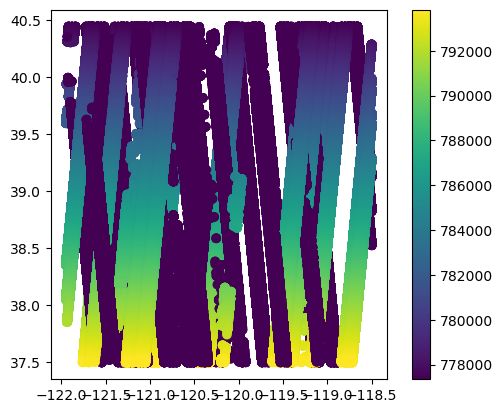

In [230]:
atl06_sr_1m_sierras_north.plot(column='segment_id', vmin=777343, vmax=793830, legend=True)

In [18]:
gdf_1m_sierras_north = atl06_sr_1m_sierras_north.copy()

In [19]:
def getFirstNonNanValue(x):
    if np.isnan(x['3dep.value']).all():
        return np.nan
    elif type(x["3dep.value"]) == float:
        return x['3dep.value']
    else:
        return x["3dep.value"][np.isfinite(x['3dep.value'])][0]
    
gdf_1m_sierras_north["3dep"] = gdf_1m_sierras_north.apply(lambda x: getFirstNonNanValue(x), axis=1)

In [227]:
gdf_1m_sierras_north.index

DatetimeIndex(['2020-10-14 00:50:21.733816832',
               '2020-10-14 00:50:21.736616448',
               '2020-10-14 00:50:21.739419648',
               '2020-10-14 00:50:21.742228224',
               '2020-10-14 00:50:21.745040640',
               '2020-10-14 00:50:21.747856384',
               '2020-10-14 00:50:21.750679808',
               '2020-10-14 00:50:21.753513728',
               '2020-10-14 00:50:21.756351744',
               '2020-10-14 00:50:21.759190272',
               ...
               '2021-10-12 07:30:43.893725952',
               '2021-10-12 07:30:43.896555520',
               '2021-10-12 07:30:43.899385600',
               '2021-10-12 07:30:43.902216192',
               '2021-10-12 07:30:43.905047040',
               '2021-10-12 07:30:43.907875840',
               '2021-10-12 07:30:43.910702848',
               '2021-10-12 07:30:43.913528064',
               '2021-10-12 07:30:43.916350464',
               '2021-10-12 07:30:43.919170304'],
              dtype=

### Combine north and south 1m data frames, ordering by timestamp:

In [20]:
gdf_1m_sierras_north['time_acq']=gdf_1m_sierras_north.index

In [21]:
gdf_1m_sierras_south['time_acq']=gdf_1m_sierras_south.index

In [22]:
gdf_1m_sierras_north

,region,pflags,gt,w_surface_window_final,dh_fit_dx,segment_id,h_sigma,rms_misfit,cycle,h_mean,...,y_atc,rgt,spot,geometry,3dep.flags,3dep.time,3dep.value,3dep.file_id,3dep,time_acq
time,,,,,,,,,,,,,,,,,,,,,
2020-10-14 00:50:21.733816832,6,0,10,3.637513,0.140617,777343,0.046696,0.427340,9,1641.960593,...,5978.400391,303,1,POINT (-120.54507 40.44682),NaN,NaN,NaN,NaN,NaN,2020-10-14 00:50:21.733816832
2020-10-14 00:50:21.736616448,6,0,10,3.000000,0.092816,777344,0.027664,0.282702,9,1644.396298,...,5978.390137,303,1,POINT (-120.54509 40.44664),NaN,NaN,NaN,NaN,NaN,2020-10-14 00:50:21.736616448
2020-10-14 00:50:21.739419648,6,0,10,3.000000,0.030053,777345,0.039307,0.318412,9,1645.587420,...,5978.399902,303,1,POINT (-120.54512 40.44646),NaN,NaN,NaN,NaN,NaN,2020-10-14 00:50:21.739419648
2020-10-14 00:50:21.742228224,6,0,10,3.000000,0.011968,777346,0.031074,0.244076,9,1645.864620,...,5978.425781,303,1,POINT (-120.54514 40.44628),NaN,NaN,NaN,NaN,NaN,2020-10-14 00:50:21.742228224
2020-10-14 00:50:21.745040640,6,0,10,3.000000,-0.024667,777347,0.025901,0.251106,9,1645.770417,...,5978.459961,303,1,POINT (-120.54516 40.4461),NaN,NaN,NaN,NaN,NaN,2020-10-14 00:50:21.745040640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-12 07:30:43.907875840,6,0,60,3.000000,0.004795,793826,0.057969,0.152810,13,-7.879185,...,-13268.161133,303,6,POINT (-121.12903 37.50083),NaN,NaN,NaN,NaN,NaN,2021-10-12 07:30:43.907875840
2021-10-12 07:30:43.910702848,6,0,60,3.000000,-0.013519,793827,0.100864,0.157084,13,-7.966012,...,-13268.536133,303,6,POINT (-121.12906 37.50065),NaN,NaN,NaN,NaN,NaN,2021-10-12 07:30:43.910702848
2021-10-12 07:30:43.913528064,6,0,60,3.000000,-0.002803,793828,0.037635,0.169694,13,-8.162467,...,-13268.904297,303,6,POINT (-121.12908 37.50047),NaN,NaN,NaN,NaN,NaN,2021-10-12 07:30:43.913528064


In [23]:
gdf_1m_sierras_merged = pd.merge_ordered(gdf_1m_sierras_north, gdf_1m_sierras_south, left_by='time_acq')

: 

### Test for 10m samplilng:

In [178]:
geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 10 meter', polygon=region)

In [179]:
# Build ATL06 Request
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}

In [180]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_10m_sierras = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_10m_sierras["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_10m_sierras["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_10m_sierras.shape[0]))

Completed in 232.595 seconds of wall-clock time
Reference Ground Tracks: [ 303  326  364  387  448  501  562  585  623  684  707  745  768  806
  829  867  890 1004 1065 1088 1126 1149 1187 1210 1248 1271 1332   59
  120  181  204  242  265  646 1309 1027  143]
Cycles: [ 9 10 11 12 13]
Received 8116680 elevations


<Axes: >

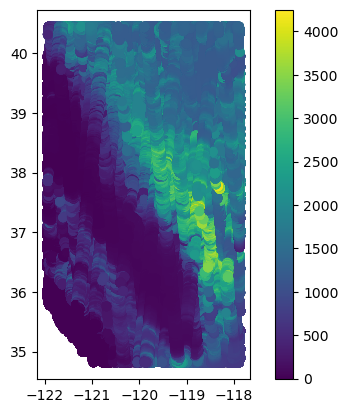

In [182]:
atl06_sr_10m_sierras.plot(column = '3dep.value', legend=True)

In [183]:
atl06_sr_10m_sierras_clip = atl06_sr_10m_sierras.clip(poly)

/opt/homebrew/Caskroom/miniforge/base/envs/sliderule_env/lib/python3.13/site-packages/geopandas/geodataframe.py:2779: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:7912
Right CRS: EPSG:4326

  return geopandas.clip(self, mask=mask, keep_geom_type=keep_geom_type, sort=sort)


<Axes: >

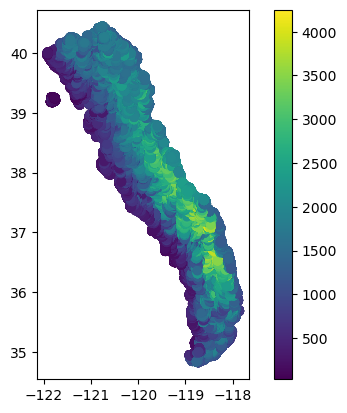

In [184]:
atl06_sr_10m_sierras_clip.plot(column = '3dep.value', legend=True)

In [221]:
atl06_sr_10m_sierras_clip

,pflags,spot,rgt,dh_fit_dx,w_surface_window_final,h_mean,cycle,segment_id,region,y_atc,gt,n_fit_photons,rms_misfit,x_atc,h_sigma,geometry,3dep.flags,3dep.value,3dep.file_id,3dep.time
time,,,,,,,,,,,,,,,,,,,,
2021-06-08 01:12:13.493028608,0,5,1149,-0.038568,3.000000,148.725775,11,202411,2,11838.295898,20,87,0.219768,4059387.75,0.031038,POINT (-119.09424 36.47758),0,178.733370,163208757248,1.354129e+09
2021-06-08 01:12:13.155565056,0,6,1149,-0.002858,3.000000,143.494063,11,202412,2,11925.696289,10,18,0.121093,4059408.00,0.031104,POINT (-119.09523 36.47768),0,173.568618,163208757248,1.354129e+09
2021-06-08 01:12:13.495866368,0,5,1149,-0.040546,3.000000,147.976190,11,202412,2,11838.270508,20,138,0.222663,4059408.00,0.018976,POINT (-119.09426 36.47776),0,178.007239,163208757248,1.354129e+09
2021-06-08 01:12:13.158392064,0,6,1149,-0.002128,3.000000,143.459429,11,202413,2,11925.708984,10,28,0.132434,4059428.00,0.025044,POINT (-119.09526 36.47786),0,173.571872,163208757248,1.354129e+09
2021-06-08 01:12:13.498703104,0,5,1149,-0.040433,3.000000,147.177079,11,202413,2,11838.257812,20,144,0.205546,4059428.00,0.017213,POINT (-119.09429 36.47794),0,176.935374,163208757248,1.354129e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-12 07:29:57.724141056,0,6,303,-0.014646,3.000000,1666.870233,13,777440,6,-12824.356445,60,15,0.143898,15571665.00,0.041056,POINT (-120.76788 40.44548),0,1689.753812,309237645312,1.354129e+09
2021-10-12 07:29:57.380820992,0,5,303,0.005934,3.000000,1658.827052,13,777439,6,-12746.794922,50,53,0.356197,15571645.00,0.049274,POINT (-120.76695 40.44559),0,1681.722908,309237645312,1.354129e+09
2021-10-12 07:29:57.378009088,0,5,303,-0.070421,3.000000,1659.449772,13,777438,6,-12746.955078,50,44,0.286826,15571625.00,0.043468,POINT (-120.76693 40.44577),0,1682.171763,309237645312,1.354129e+09


In [51]:
# Build ATL06 Request
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}

In [50]:
type(atl06_sr)

geopandas.geodataframe.GeoDataFrame

In [49]:
gdf = atl06_sr[atl06_sr["3dep.value"].notna()]

KeyError: '3dep.value'

### Now test over tuolumne using a bounding box and the 10m 3DEP:

In [ ]:
# rough tuolumne bounding box
38.2, -119.8, 37.7, -119.2

(38.2, -119.8, 37.7, -119.2)

In [56]:
#grand mesa bounding box:
region = [  {"lon": -119.8, "lat": 37.7},
            {"lon": -119.2, "lat": 37.7},
            {"lon": -119.2, "lat": 38.2},
            {"lon": -119.8, "lat": 38.2},
            {"lon": -119.8, "lat": 37.7}  ]

# @pytest.mark.network
# class Test3DEP_1meter:
#     def test_sample(self, init):
#         geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=region)
#         gdf = raster.sample("usgs3dep-1meter-dem", [[-108.0,39.0]], {"catalog": geojson})
#         assert init
#         assert len(gdf) >= 4

In [57]:
region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

In [71]:
geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 10 meter', polygon=region)

In [ ]:
geojson

'{"type": "FeatureCollection", "features": [{"type": "Feature", "id": "5eaa4a0582cefae35a21ee8c", "geometry": {"type": "Polygon", "coordinates": [[[-108.117274181, 38.9003581843], [-107.998021739, 38.9003581843], [-107.998021739, 38.987435717], [-108.117274181, 38.987435717], [-108.117274181, 38.9003581843]]]}, "properties": {"datetime": "2020-11-17T19:08:25.219000+01:00", "url": "https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_MesaCo_QL2_UTM12_2016/TIFF/USGS_one_meter_x23y432_CO_MesaCo_QL2_UTM12_2016.tif"}}, {"type": "Feature", "id": "5eaa4a0582cefae35a21ee8e", "geometry": {"type": "Polygon", "coordinates": [[[-108.121233424, 38.9903575086], [-108.001829768, 38.9903575086], [-108.001829768, 39.0774149519], [-108.121233424, 39.0774149519], [-108.121233424, 38.9903575086]]]}, "properties": {"datetime": "2020-11-17T19:08:25.977000+01:00", "url": "https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_MesaCo_QL2_UTM12_2016/TIFF/USGS_one_meter_x23

In [72]:
# Build ATL06 Request
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}

In [73]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_10m = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_10m["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_10m["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_10m.shape[0]))

Completed in 19.991 seconds of wall-clock time
Reference Ground Tracks: [ 684  707 1126 1149  265  623 1210  181]
Cycles: [ 9 10 11 12 13]
Received 113632 elevations


In [74]:
gdf_10m = atl06_sr_10m[atl06_sr_10m["3dep.value"].notna()]

In [75]:
gdf_10m

,pflags,spot,rgt,dh_fit_dx,w_surface_window_final,h_mean,cycle,segment_id,region,y_atc,gt,n_fit_photons,rms_misfit,x_atc,h_sigma,geometry,3dep.flags,3dep.value,3dep.file_id,3dep.time
time,,,,,,,,,,,,,,,,,,,,
2020-11-07 23:35:21.118647040,0,1,684,0.002941,3.000000,2324.547788,9,790264,6,6068.183105,10,14,0.090716,15828625.0,0.096130,POINT (-119.79496 38.12538),0,2348.997368,25769803776,1.354129e+09
2020-11-07 23:35:21.121492992,0,1,684,-0.002342,3.000000,2324.589531,9,790265,6,6068.083496,10,51,0.123311,15828645.0,0.020325,POINT (-119.79499 38.1252),0,2348.931935,25769803776,1.354129e+09
2020-11-07 23:35:21.124338688,0,1,684,-0.005483,3.000000,2324.524838,9,790266,6,6067.997070,10,48,0.133345,15828665.0,0.023245,POINT (-119.79501 38.12502),0,2348.790086,25769803776,1.354129e+09
2020-11-07 23:35:21.127185408,0,1,684,-0.005322,3.000000,2324.432745,9,790267,6,6067.937988,10,17,0.121056,15828685.0,0.035076,POINT (-119.79503 38.12484),0,2348.640914,25769803776,1.354129e+09
2020-11-07 23:35:21.130028544,0,1,684,-0.052323,3.000000,2323.534175,9,790268,6,6067.924316,10,28,0.235443,15828705.0,0.053561,POINT (-119.79506 38.12466),0,2348.041057,25769803776,1.354129e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-09 19:20:22.385134848,0,3,265,-0.018709,3.000000,2821.202262,13,211864,2,-9883.971680,30,46,0.110891,4248952.5,0.032589,POINT (-119.57442 38.19652),0,2843.286733,98784247808,1.354129e+09
2021-10-09 19:20:22.387963136,0,3,265,-0.003660,3.000000,2820.992043,13,211865,2,-9884.078125,30,83,0.146463,4248972.5,0.016116,POINT (-119.57444 38.1967),0,2844.812616,98784247808,1.354129e+09
2021-10-09 19:20:22.390786304,0,3,265,0.006581,3.000000,2821.050031,13,211866,2,-9884.161133,30,37,0.138214,4248992.5,0.062729,POINT (-119.57447 38.19688),0,2845.263792,98784247808,1.354129e+09


In [76]:
gdf_1m

,pflags,spot,rgt,dh_fit_dx,w_surface_window_final,h_mean,cycle,segment_id,region,y_atc,...,n_fit_photons,rms_misfit,x_atc,h_sigma,geometry,3dep.flags,3dep.value,3dep.file_id,3dep.time,3dep
time,,,,,,,,,,,,,,,,,,,,,
2020-11-07 23:35:21.118647040,0,1,684,0.002941,3.000000,2324.547788,9,790264,6,6068.183105,...,14,0.090716,15828625.0,0.096130,POINT (-119.79496 38.12538),"[0, 0]","[2324.567201152069, nan]","[34359738368, 34359738369]","[1432961479.0, 1309642695.0]",2324.567201
2020-11-07 23:35:21.121492992,0,1,684,-0.002342,3.000000,2324.589531,9,790265,6,6068.083496,...,51,0.123311,15828645.0,0.020325,POINT (-119.79499 38.1252),"[0, 0]","[2324.4822973452747, nan]","[34359738368, 34359738369]","[1432961479.0, 1309642695.0]",2324.482297
2020-11-07 23:35:21.124338688,0,1,684,-0.005483,3.000000,2324.524838,9,790266,6,6067.997070,...,48,0.133345,15828665.0,0.023245,POINT (-119.79501 38.12502),"[0, 0]","[2324.292657602935, nan]","[34359738368, 34359738369]","[1432961479.0, 1309642695.0]",2324.292658
2020-11-07 23:35:21.127185408,0,1,684,-0.005322,3.000000,2324.432745,9,790267,6,6067.937988,...,17,0.121056,15828685.0,0.035076,POINT (-119.79503 38.12484),"[0, 0]","[2324.0934972669565, nan]","[34359738368, 34359738369]","[1432961479.0, 1309642695.0]",2324.093497
2020-11-07 23:35:21.130028544,0,1,684,-0.052323,3.000000,2323.534175,9,790268,6,6067.924316,...,28,0.235443,15828705.0,0.053561,POINT (-119.79506 38.12466),"[0, 0]","[2323.8633325664982, nan]","[34359738368, 34359738369]","[1432961479.0, 1309642695.0]",2323.863333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-09 19:20:22.385134848,0,3,265,-0.018709,3.000000,2821.202262,13,211864,2,-9883.971680,...,46,0.110891,4248952.5,0.032589,POINT (-119.57442 38.19652),"[0, 0]","[2819.9418441641133, nan]","[55834574856, 55834574857]","[1432961430.0, 1309642686.0]",2819.941844
2021-10-09 19:20:22.387963136,0,3,265,-0.003660,3.000000,2820.992043,13,211865,2,-9884.078125,...,83,0.146463,4248972.5,0.016116,POINT (-119.57444 38.1967),"[0, 0]","[2820.867459958159, nan]","[55834574856, 55834574857]","[1432961430.0, 1309642686.0]",2820.867460
2021-10-09 19:20:22.390786304,0,3,265,0.006581,3.000000,2821.050031,13,211866,2,-9884.161133,...,37,0.138214,4248992.5,0.062729,POINT (-119.57447 38.19688),"[0, 0]","[2820.428818397419, nan]","[55834574856, 55834574857]","[1432961430.0, 1309642686.0]",2820.428818


In [77]:
gdf_10m['3dep_1m_10m_dif'] = gdf_1m['3dep'] - gdf_10m['3dep.value']

<Axes: >

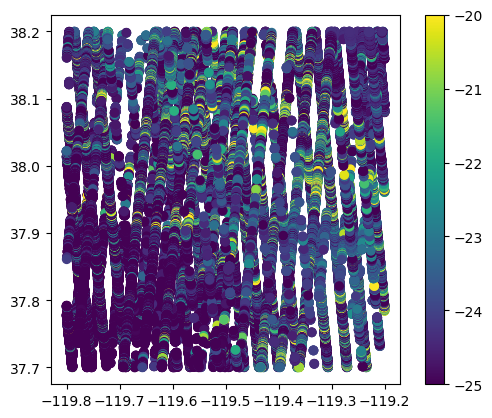

In [85]:
gdf_10m.plot(column='3dep_1m_10m_dif', legend=True, vmin=-25, vmax=-20)

In [86]:
gdf_10m['3dep_1m_10m_dif'].describe()

count    113632.000000
mean        -24.434844
std           2.952980
min        -460.602778
25%         -25.389144
50%         -24.406021
75%         -23.602804
max         411.401762
Name: 3dep_1m_10m_dif, dtype: float64

In [96]:
np.sqrt(len(gdf_10m['3dep_1m_10m_dif']))

np.float64(337.0934588508059)

''

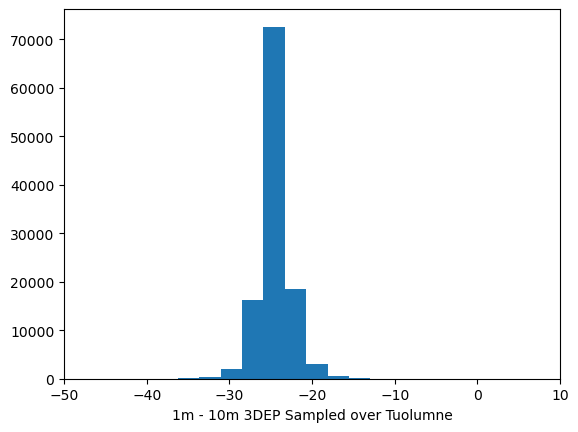

In [102]:
fig, ax = plt.subplots()

ax.hist(gdf_10m['3dep_1m_10m_dif'], bins=337)
ax.set_xlabel('1m - 10m 3DEP Sampled over Tuolumne')
ax.set_xlim(-50,10)
;

### Test 3DEP 10m sampling at GM:

In [103]:
region = [  {"lon": -108.3435200747503, "lat": 38.89102961045247},
            {"lon": -107.7677425431139, "lat": 38.90611184543033},
            {"lon": -107.7818591266989, "lat": 39.26613714985466},
            {"lon": -108.3605610678553, "lat": 39.25086131372244},
            {"lon": -108.3435200747503, "lat": 38.89102961045247}  ]

# @pytest.mark.network
# class Test3DEP_1meter:
#     def test_sample(self, init):
#         geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=region)
#         gdf = raster.sample("usgs3dep-1meter-dem", [[-108.0,39.0]], {"catalog": geojson})
#         assert init
#         assert len(gdf) >= 4

In [104]:
region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

In [105]:
geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=region)

In [ ]:
geojson

'{"type": "FeatureCollection", "features": [{"type": "Feature", "id": "5eaa4a0582cefae35a21ee8c", "geometry": {"type": "Polygon", "coordinates": [[[-108.117274181, 38.9003581843], [-107.998021739, 38.9003581843], [-107.998021739, 38.987435717], [-108.117274181, 38.987435717], [-108.117274181, 38.9003581843]]]}, "properties": {"datetime": "2020-11-17T19:08:25.219000+01:00", "url": "https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_MesaCo_QL2_UTM12_2016/TIFF/USGS_one_meter_x23y432_CO_MesaCo_QL2_UTM12_2016.tif"}}, {"type": "Feature", "id": "5eaa4a0582cefae35a21ee8e", "geometry": {"type": "Polygon", "coordinates": [[[-108.121233424, 38.9903575086], [-108.001829768, 38.9903575086], [-108.001829768, 39.0774149519], [-108.121233424, 39.0774149519], [-108.121233424, 38.9903575086]]]}, "properties": {"datetime": "2020-11-17T19:08:25.977000+01:00", "url": "https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_MesaCo_QL2_UTM12_2016/TIFF/USGS_one_meter_x23

In [106]:
# Build ATL06 Request
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}

In [107]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_10m_gm = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_10m_gm["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_10m_gm["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_10m_gm.shape[0]))

Completed in 24.231 seconds of wall-clock time
Reference Ground Tracks: [ 714  737 1156 1179  211  234  295]
Cycles: [ 9 10 11 12 13]


AttributeError: 'GeoDataFrame' object has no attribute 'shape_10m_gm'

In [108]:
gdf_10m_gm = atl06_sr_10m_gm[atl06_sr_10m_gm["3dep.value"].notna()]

In [109]:
def getFirstValue(x):
    if type(x["3dep.value"]) == float:
        return x['3dep.value']
    else:
        return x['3dep.value'][0]
gdf_10m_gm["3dep"] = gdf_10m_gm.apply(lambda x: getFirstValue(x), axis=1)

<Axes: >

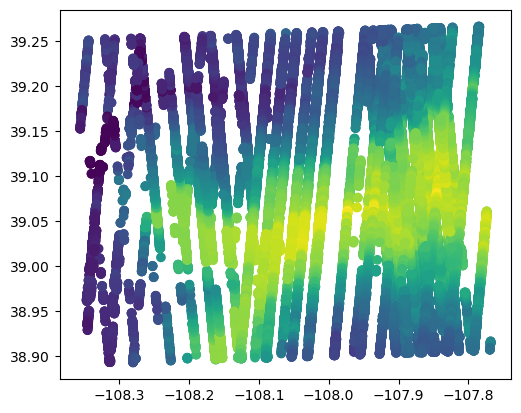

In [110]:
gdf_10m_gm.plot(column='3dep')

In [ ]:
# def getFirstNonNanValue(x):
#     if np.isnan(x['3dep.value']).all():
#         return np.nan
#     else:
#         return x["3dep.value"][np.isfinite(x['3dep.value'])][0]
    
# gdf["3dep"] = gdf.apply(lambda x: getFirstNonNanValue(x), axis=1)

## Specify parameters for ATL06-SR processing

In [23]:
# Build ATL06 Request
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}

## Calculate ATL06-SR Elevations from ATL03 Photons using SlideRule

In [11]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 16.018 seconds of wall-clock time
Reference Ground Tracks: [ 265  707 1126  181  623  684 1149 1210]
Cycles: [ 1  2  3  4  5  6  7  8  9 10 11 12 13]
Received 262138 elevations


## Plot ATL06-SR Results

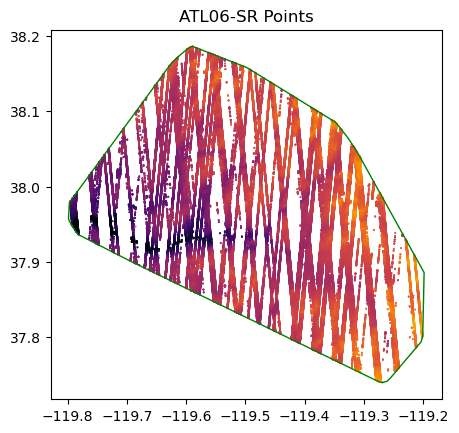

In [12]:
f, ax = plt.subplots()
ax.set_title("ATL06-SR Points")
ax.set_aspect('equal')
atl06_sr.plot(ax=ax, column='h_mean', cmap='inferno', s=0.1)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

In [13]:
atl06_sr

,dh_fit_dx,gt,h_mean,n_fit_photons,x_atc,y_atc,pflags,region,h_sigma,rms_misfit,rgt,cycle,segment_id,w_surface_window_final,spot,geometry
time,,,,,,,,,,,,,,,,
2018-10-15 23:22:19.488531712,-0.002099,50,2442.645168,12,4211684.5,-5552.389160,0,2,0.032415,0.110804,265,1,210005,3.0,2,POINT (-119.58334 37.85861)
2018-10-15 23:22:19.491344128,0.009009,50,2442.787974,25,4211704.5,-5552.401367,0,2,0.025957,0.121344,265,1,210006,3.0,2,POINT (-119.58337 37.85879)
2018-10-15 23:22:19.494166528,0.000001,50,2442.887776,18,4211725.0,-5552.413086,0,2,0.070636,0.088478,265,1,210007,3.0,2,POINT (-119.58339 37.85897)
2018-10-15 23:22:19.821067520,-0.013643,60,2456.821205,143,4211644.5,-5624.697266,0,2,0.030358,0.345901,265,1,210003,3.0,1,POINT (-119.58248 37.8583)
2018-10-15 23:22:19.823790592,-0.035756,60,2456.217479,137,4211664.5,-5624.702148,0,2,0.042715,0.482781,265,1,210004,3.0,1,POINT (-119.5825 37.85848)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-09 19:20:21.927475712,0.079683,10,2729.332460,60,4245584.5,-6658.280273,0,2,0.042478,0.166255,265,13,211696,3.0,1,POINT (-119.60744 38.16357)
2021-10-09 19:20:22.047049216,-0.004578,30,2943.889641,23,4246547.0,-9853.813477,0,2,0.171765,0.200292,265,13,211744,3.0,3,POINT (-119.57217 38.17492)
2021-10-09 19:20:22.049860352,0.007832,30,2943.859328,49,4246567.0,-9854.179688,0,2,0.024458,0.168479,265,13,211745,3.0,3,POINT (-119.57219 38.1751)


In [16]:
atl06_sr.crs

<Geographic 3D CRS: EPSG:7912>
Name: ITRF2014
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
- h[up]: Ellipsoidal height (metre)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: International Terrestrial Reference Frame 2014
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

## Retrieve ATL06 Elevations Directly using `icesat2.h5p` API

This method of reading H5 data directly is the recommended method and runs faster than `icesat2.h5` as each dataset is read in parallel on the server and shares a common cache. The code below has a couple other optimizations including only sampling every 10th coordinate for point inclusion, and reading the lat,lon information first and then reading only the necessary heights.  

See https://nsidc.org/data/atl06 for the source dataset.

In [14]:
# read ATL06 resource and return heights within polygon
def subsetted_read(resource, polygon, transformer):

    heights = []
    latitudes = []
    longitudes = []
    api_time = 0

    try:

        # List of tracks to read
        tracks = ["1l", "1r", "2l", "2r", "3l", "3r"]

        # Build list of each lat,lon dataset to read
        geodatasets = []
        for track in tracks:
            prefix = "/gt"+track+"/land_ice_segments/"
            geodatasets.append({"dataset": prefix+"latitude", "startrow": 0, "numrows": -1})
            geodatasets.append({"dataset": prefix+"longitude", "startrow": 0, "numrows": -1})

        # Read lat,lon from resource
        api_start = time.perf_counter()
        geocoords = h5.h5p(geodatasets, resource, "icesat2")
        api_stop = time.perf_counter()
        api_time += (api_stop - api_start)
        
        # Build list of the subsetted h_li datasets to read
        hidatasets = []
        for track in tracks:
            prefix = "/gt"+track+"/land_ice_segments/"
            lat_dataset = geocoords[prefix+"latitude"]
            lon_dataset = geocoords[prefix+"longitude"]
            startrow = -1
            numrows = -1
            index = 0
            while index < len(lat_dataset):
                lat = lat_dataset[index]
                lon = lon_dataset[index]
                c = transformer.transform(lat, lon)
                point = Point(c[0], c[1])
                intersect = point.within(polygon)
                if startrow == -1 and intersect:
                    startrow = index
                elif startrow != -1 and not intersect:
                    break
                index += 10 # only sample values for speed increase
            if startrow >= 0:
                numrows = index - startrow
            if numrows > 0:
                hidatasets.append({"dataset": prefix+"h_li", "startrow": startrow, "numrows": numrows, "prefix": prefix})

        # Read h_li from resource
        if len(hidatasets) > 0:
            api_start = time.perf_counter()
            hivalues = h5.h5p(hidatasets, resource, "icesat2")
            api_stop = time.perf_counter()
            api_time += (api_stop - api_start)

        # Append results
        for entry in hidatasets:
            heights += hivalues[entry["prefix"]+"h_li"].tolist()
            latitudes += geocoords[entry["prefix"]+"latitude"][entry["startrow"]:entry["startrow"]+entry["numrows"]].tolist()
            longitudes += geocoords[entry["prefix"]+"longitude"][entry["startrow"]:entry["startrow"]+entry["numrows"]].tolist()

    except Exception as e:
        pass
        
    # Return results
    return {"resource":  resource,
            "h_li":      heights,
            "latitude":  latitudes,
            "longitude": longitudes,
            "time":      api_time}

In [16]:
# Initialize Total Time Spent Inside API
api_total_time = 0

# Latch Start Time
perf_start = time.perf_counter()

# Query ATL06 Files from NASA CMR System
resources = earthdata.cmr(polygon=region, short_name='ATL06')
print('Retrieved %s resources that intersect region' % (len(resources)))

# Create Projection Transformer
transformer = Transformer.from_crs(4326, 3857) # GPS to Web Mercator

# Project Polygon
pregion = []
for point in region:
    ppoint = transformer.transform(point["lat"], point["lon"])
    pregion.append(ppoint)
polygon = Polygon(pregion)

# Initialize Result Dataset
results = {"latitude": [], "longitude": [], "h_li":[]}

# Update Available Servers #
num_servers, _ = sliderule.update_available_servers()
print('Allocating %d workers across %d processing nodes' % (num_servers, num_servers))

# Make Parallel Processing Requests
with concurrent.futures.ThreadPoolExecutor(max_workers=num_servers) as executor:
    futures = [executor.submit(subsetted_read, resource, polygon, transformer) for resource in resources]
    # Wait for Results
    result_cnt = 0
    for future in concurrent.futures.as_completed(futures):
        result_cnt += 1
        result = future.result()
        print('%d results returned for %s (%d out of %d)' % (len(result["h_li"]), result["resource"], result_cnt, len(resources)))
        results["h_li"] += result["h_li"]
        results["latitude"] += result["latitude"]
        results["longitude"] += result["longitude"]
        api_total_time += result["time"]

# Latch Stop Time
perf_stop = time.perf_counter()
perf_duration = perf_stop - perf_start

# Build GeoDataframe of ATL06 Standard Data Product
geometry = gpd.points_from_xy(results["longitude"], results["latitude"])
df = gpd.pd.DataFrame(results)
atl06_sdp = gpd.GeoDataFrame(df, geometry=geometry)

# Filter Height Values
atl06_sdp = atl06_sdp[atl06_sdp["h_li"] < 10000]

# Print Statistics
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Spent {:.3f} concurrent seconds waiting for api".format(api_total_time))
print("Retrieved {} valid elevations out of {} total elevations".format(len(atl06_sdp), len(results["h_li"])))

Retrieved 129 resources that intersect region
Allocating 7 workers across 7 processing nodes
9990 results returned for ATL06_20181211084726_11260106_006_02.h5 (1 out of 129)
1640 results returned for ATL06_20190212173531_07070202_006_02.h5 (2 out of 129)
60 results returned for ATL06_20190114185917_02650202_006_02.h5 (3 out of 129)
10070 results returned for ATL06_20190312042725_11260206_006_02.h5 (4 out of 129)
5760 results returned for ATL06_20190410030325_01810306_006_02.h5 (5 out of 129)
0 results returned for ATL06_20190313161135_11490202_006_03.h5 (6 out of 129)
620 results returned for ATL06_20190109072332_01810206_006_02.h5 (7 out of 129)


: 

: 

## Trim ATL06 points to region polygon

In [ ]:
# Create shapely polygon
pregion = Polygon(zip(region_lon, region_lat))

# Using geopandas
idx = atl06_sdp.within(pregion)
atl06_sdp = atl06_sdp[idx]

## Plot ATL06-SR vs. ATL06

In [ ]:
# Set color ramp limits
vmin, vmax = atl06_sdp['h_li'].quantile((0.02, 0.98))

# Create dictionary of common keyword arguments
plot_kw = {'cmap':'inferno', 's':0.1, 'vmin':vmin, 'vmax':vmax}

f, axa = plt.subplots(2,1, figsize=(10,10)) # sharex=True, sharey=True
axa[0].set_title("ATL06-SR Points")
atl06_sr.plot(ax=axa[0], column='h_mean', **plot_kw)
axa[1].set_title("ATL06 Points")
atl06_sdp.plot(ax=axa[1], column='h_li', **plot_kw)

for ax in axa:
    # Plot the region polygon
    ax.plot(region_lon, region_lat, linewidth=1, color='g')
    ax.set_aspect('equal');
    ax.set_facecolor('lightgray')